# EECS 6320 — Final Deliverable - Oversampling
## Oversampling

**Implementing Final deliverable:**
- Use baseline code provided
- Create 3 separate dataframes, one for each sensitive attribute
- Oversample each dataframe with the majority feature
- Train the Random Forest model on the baseline and oversampled datasets
- Evaluate each model across all evaluation and fairness metrics

### Oversampling Objective
The goal of this method is to see how a basic strategy such as oversampling would affect the bias distribution of the dataset.

### Fairness Metrics Reported
- **Group Disparity Difference** (demographic parity gap / selection-rate gap)
- **Equal Opportunity Gap** (TPR gap)
- **False Positive Rate Gap**

### Text Blocks
Sections including text are the code blocks changed from the baseline. They provide additional commentary on the purpose of the new code.


In [1]:
# Core imports
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
from pathlib import Path
import os
import numpy as np
import pandas as pd
from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.neighbors import NearestNeighbors


import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# Set random seed
SEEDS = [42, 143, 244, 345, 446]
SEED  = SEEDS[0]
np.random.seed(SEED)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

In [2]:
# Mount Google Drive
drive.mount('/content/drive')

# Locate dataset automatically (works locally and in Colab)
candidate_paths = [
    Path("/mnt/data/21stMortgageCorporation_header.csv"),
    Path("./21stMortgageCorporation_header.csv"),
    Path("/content/21stMortgageCorporation_header.csv"),
    Path("/content/drive/MyDrive/EECS6320/Dataset/21stMortgageCorporation_header.csv"),
]

# Check all data paths to find applicable path to csv
DATA_PATH = None
for p in candidate_paths:
    if p.exists():
        DATA_PATH = p
        break

# If no path is found, raise error
if DATA_PATH is None:
    raise FileNotFoundError("21stMortgageCorporation_header.csv not found. Upload it or update candidate_paths.")

# Set an output directory for results
OUT_DIR = Path("/mnt/data/eecs6320_q2_outputs") if Path("/mnt/data").exists() else Path("./eecs6320_q2_outputs - oversampled")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Print input and output information
print(f"Using data file: {DATA_PATH}")
print(f"Saving outputs to: {OUT_DIR.resolve()}")

Mounted at /content/drive
Using data file: /content/drive/MyDrive/EECS6320/Dataset/21stMortgageCorporation_header.csv
Saving outputs to: /content/eecs6320_q2_outputs - oversampled


In [3]:
# Define the target column
TARGET_COL = "action_taken"

# Define numeric columns
BASELINE_NUMERIC_COLS = [
    "loan_amount",
    "income",
    "property_value",
    "loan_term",
]

# Define categorical columns
BASELINE_CATEGORICAL_COLS = [
    "occupancy_type",
    "state_code",
    "county_code",
    "applicant_credit_scoring_model",
    "debt_to_income_ratio",
    "interest_only_payment",
]

# Define sensitive attribute columns
SENSITIVE_COLS = [
    "applicant_sex",
    "applicant_race_1",
    "applicant_age",
]

# Combine all columns
ALL_REQUIRED_COLS = BASELINE_NUMERIC_COLS + BASELINE_CATEGORICAL_COLS + SENSITIVE_COLS + [TARGET_COL]

# Print all columns
ALL_REQUIRED_COLS

['loan_amount',
 'income',
 'property_value',
 'loan_term',
 'occupancy_type',
 'state_code',
 'county_code',
 'applicant_credit_scoring_model',
 'debt_to_income_ratio',
 'interest_only_payment',
 'applicant_sex',
 'applicant_race_1',
 'applicant_age',
 'action_taken']

In [4]:
# Read only required columns.
# IMPORTANT: the uploaded 21st Mortgage Corporation file is pipe-delimited, not comma-delimited.
raw_df = pd.read_csv(DATA_PATH, sep="|", usecols=ALL_REQUIRED_COLS, dtype="string")

# Print dataframe statistics and header
print("Raw shape:", raw_df.shape)
raw_df.head()

Raw shape: (163986, 14)


,occupancy_type,loan_amount,action_taken,state_code,county_code,applicant_race_1,applicant_sex,applicant_age,income,applicant_credit_scoring_model,debt_to_income_ratio,loan_term,interest_only_payment,property_value
0,1,105000,3,LA,22031,5,1,25-34,<NA>,9,<NA>,276,2,<NA>
1,1,55000,6,SC,45035,7,4,8888,<NA>,9,<NA>,180,2,55000
2,1,55000,6,NC,37081,7,4,8888,<NA>,9,<NA>,180,2,55000
3,1,45000,6,NC,37183,7,4,8888,<NA>,9,<NA>,144,2,45000
4,1,35000,6,TX,48121,7,4,8888,<NA>,9,<NA>,120,2,35000


In [5]:
# Clean raw strings
df = raw_df.copy()
df = df.replace(["?", "<NA>", "NA", "N/A", "null", "None", ""], np.nan)
df = df.replace(r"^\s*$", np.nan, regex=True)

# For all columns, remove whitespace
for col in df.columns:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

# Keep valid target values for a clean approval-vs-denial baseline
df = df[df[TARGET_COL].isin(["1", "3"])].copy()

# Keep valid sensitive-attribute categories used in the current project design
valid_ages = ["<25", "25-34", "35-44", "45-54", "55-64", "65-74", ">74"]
df = df[df["applicant_sex"].isin(["1", "2"])].copy()
df = df[df["applicant_race_1"].isin(["2", "3", "5"])].copy()
df = df[df["applicant_age"].isin(valid_ages)].copy()

# Convert numeric baseline columns
for col in BASELINE_NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Binary target: 1=approved, 0=denied
df["target"] = df[TARGET_COL].map({"1": 1, "3": 0}).astype("int64")

# Cast categoricals explicitly
for col in BASELINE_CATEGORICAL_COLS + SENSITIVE_COLS:
    df[col] = df[col].astype("object")

# Force any lingering pandas NA to np.nan
df = df.replace({pd.NA: np.nan})

# Print preprocessing results
print("Filtered / cleaned shape:", df.shape)
print("\nTarget distribution (1=approved, 0=denied):")
print(df["target"].value_counts(dropna=False))
print("\nMissing values after filtering:")
print(df[ALL_REQUIRED_COLS].isna().sum().sort_values(ascending=False))

Filtered / cleaned shape: (85241, 15)

Target distribution (1=approved, 0=denied):
target
0    62986
1    22255
Name: count, dtype: int64

Missing values after filtering:
property_value                    1731
income                            1730
debt_to_income_ratio              1723
loan_amount                          0
occupancy_type                       0
loan_term                            0
state_code                           0
county_code                          0
applicant_credit_scoring_model       0
interest_only_payment                0
applicant_sex                        0
applicant_race_1                     0
applicant_age                        0
action_taken                         0
dtype: int64


In [6]:
# Save cleaned Q2 dataset for reproducibility
clean_q2_path = OUT_DIR / "q2_cleaned_dataset.csv"
df.to_csv(clean_q2_path, index=False)
print(f"Saved cleaned dataset to: {clean_q2_path}")

Saved cleaned dataset to: eecs6320_q2_outputs - oversampled/q2_cleaned_dataset.csv


In [7]:
# Define X, Y, and sensitive dataframe
X = df[BASELINE_NUMERIC_COLS + BASELINE_CATEGORICAL_COLS + SENSITIVE_COLS].copy()
y = df["target"].copy()

# Define the train/test split percentage
test_split = 0.25

# Create train and test splits for X, Y, and sensitive.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_split,
    random_state=SEED,
    stratify=y,
)

# Print train test split results
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).rename("proportion"))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).rename("proportion"))

Train shape: (63930, 13)
Test shape: (21311, 13)

Train target distribution:
target
0    0.738918
1    0.261082
Name: proportion, dtype: float64

Test target distribution:
target
0    0.738914
1    0.261086
Name: proportion, dtype: float64


### Step 1: Create additional dataframes

Additional dataframes are created, 1 for each sensitive attribute. Each dataframe finds the majority feature in its column and oversamples minority features with replacement till they are equal with the majority feature count.

In [8]:
# Combine X_train and y_train for easier filtering
train_df = X_train.copy()
train_df["target"] = y_train.values

# The sensitive feature columns to oversample
OVERSAMPLE_COLS = {
    "applicant_sex":    "os_sex",
    "applicant_race_1": "os_race",
    "applicant_age":    "os_age",
}

# Readable label maps for printing
LABEL_MAPS = {
    "applicant_sex":    {"1": "Male",  "2": "Female"},
    "applicant_race_1": {"2": "Asian", "3": "Black", "5": "White"},
    "applicant_age":    {},  # already readable
}

def apply_label_map(series, col):
    m = LABEL_MAPS.get(col, {})
    if m:
        return series.rename(index=lambda x: m.get(str(x), x))
    return series

# Find the current distribution of features in each oversampled column
for col in OVERSAMPLE_COLS:
    print(f"\n── {col} ──")
    group_counts = (
        train_df[train_df["target"] == 1]
        .groupby(col)
        .size()
        .sort_values(ascending=False)
    )
    labeled = apply_label_map(group_counts, col)
    labeled.index.name = None
    print(labeled.to_string())

# Build each oversampled dataframe independently from clean train_df
oversampled_dfs = {}

# Find the number of samples to add, and add them to each dataframe
for col, df_name in OVERSAMPLE_COLS.items():
    group_counts = (
        train_df[train_df["target"] == 1]
        .groupby(col)
        .size()
        .sort_values(ascending=False)
    )
    max_count = group_counts.max()
    rows_to_add = []

    for group, count in group_counts.items():
        num_to_add = max_count - count
        if num_to_add == 0:
            continue
        minority_pos_df = train_df[(train_df[col] == group) & (train_df["target"] == 1)]
        oversampled = minority_pos_df.sample(n=num_to_add, replace=True, random_state=SEED)
        rows_to_add.append(oversampled)

    result = pd.concat([train_df] + rows_to_add, ignore_index=True)
    oversampled_dfs[df_name] = result

# Define 3 new aliases for the dataframes
os_sex  = oversampled_dfs["os_sex"]
os_race = oversampled_dfs["os_race"]
os_age  = oversampled_dfs["os_age"]

# Print the results of oversampling
for col, df_name in OVERSAMPLE_COLS.items():
    print(f"\n── {df_name} ({col}) ──")
    df = oversampled_dfs[df_name]
    group_counts_after = (
        df[df["target"] == 1]
        .groupby(col)
        .size()
        .sort_values(ascending=False)
    )
    labeled = apply_label_map(group_counts_after, col)
    labeled.index.name = None
    print(labeled.to_string())
    print(f"Train size: {len(train_df)} → {len(df)}")


── applicant_sex ──
Male      9426
Female    7265

── applicant_race_1 ──
White    14424
Black     2094
Asian      173

── applicant_age ──
25-34    4366
35-44    3519
45-54    2997
55-64    2528
<25      1676
65-74    1305
>74       300

── os_sex (applicant_sex) ──
Male      9426
Female    9426
Train size: 63930 → 66091

── os_race (applicant_race_1) ──
Asian    14424
Black    14424
White    14424
Train size: 63930 → 90511

── os_age (applicant_age) ──
25-34    4366
35-44    4366
45-54    4366
55-64    4366
65-74    4366
<25      4366
>74      4366
Train size: 63930 → 77801


### Step 2: Train oversampled datasets

The oversampled datasets and the original baseline dataset is trained used Random Forest. Each training cycle resets the preprocessor and model to avoid leakage.

In [9]:
# Store trained models and predictions across all seeds
trained_models = {}
predictions    = {}

for seed in SEEDS:
    print(f"{'='*50}\nRun with SEED={seed}\n{'='*50}")

    # Define all four training configurations: baseline + three oversampled
    training_configs = {
        "baseline": (X_train, y_train),
        "os_sex":   (os_sex.drop(columns=["target"]),  os_sex["target"]),
        "os_race":  (os_race.drop(columns=["target"]), os_race["target"]),
        "os_age":   (os_age.drop(columns=["target"]),  os_age["target"]),
    }

    for name, (X_tr, y_tr) in training_configs.items():
        print(f"Training '{name}' model  (train size: {len(X_tr)})...")

        preprocessor = ColumnTransformer(
            transformers=[
                ("num", Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                ]), BASELINE_NUMERIC_COLS),
                ("cat", Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]), BASELINE_CATEGORICAL_COLS),
            ]
        )

        model = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", RandomForestClassifier(
                    n_estimators=400,
                    min_samples_leaf=2,
                    class_weight="balanced_subsample",
                    random_state=seed,
                    n_jobs=-1,
                )),
            ]
        )

        model.fit(X_tr, y_tr)

        y_pred  = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]

        trained_models[(seed, name)] = model
        predictions[(seed, name)]    = {"y_pred": y_pred, "y_score": y_score}

        print(f"  ✓ '{name}' trained successfully.\n")

print("All models trained across all seeds.")

Run with SEED=42
Training 'baseline' model  (train size: 63930)...
  ✓ 'baseline' trained successfully.

Training 'os_sex' model  (train size: 66091)...
  ✓ 'os_sex' trained successfully.

Training 'os_race' model  (train size: 90511)...
  ✓ 'os_race' trained successfully.

Training 'os_age' model  (train size: 77801)...
  ✓ 'os_age' trained successfully.

Run with SEED=143
Training 'baseline' model  (train size: 63930)...
  ✓ 'baseline' trained successfully.

Training 'os_sex' model  (train size: 66091)...
  ✓ 'os_sex' trained successfully.

Training 'os_race' model  (train size: 90511)...
  ✓ 'os_race' trained successfully.

Training 'os_age' model  (train size: 77801)...
  ✓ 'os_age' trained successfully.

Run with SEED=244
Training 'baseline' model  (train size: 63930)...
  ✓ 'baseline' trained successfully.

Training 'os_sex' model  (train size: 66091)...
  ✓ 'os_sex' trained successfully.

Training 'os_race' model  (train size: 90511)...
  ✓ 'os_race' trained successfully.

Train

### Step 3: Output metric results

After training each model, its results are compared for accuracy, balanced accuracy, ROC-AUC, precision, recall, f1-score, and macro f1-score. The results are stored and printed into a list to present any findings.

In [10]:
# Unique config names (independent of seed)
config_names = ["baseline", "os_sex", "os_race", "os_age"]

# ── Scalar metrics ────────────────────────────────────────────────────────────
# Accumulate per-seed metrics
raw_metrics = defaultdict(lambda: defaultdict(list))

for (seed, name), preds in predictions.items():
    y_pred  = preds["y_pred"]
    y_score = preds["y_score"]
    raw_metrics[name]["Accuracy"].append(accuracy_score(y_test, y_pred))
    raw_metrics[name]["Balanced Accuracy"].append(balanced_accuracy_score(y_test, y_pred))
    raw_metrics[name]["ROC-AUC"].append(roc_auc_score(y_test, y_score))

# Average across seeds
metrics = {
    name: {k: np.mean(v) for k, v in raw_metrics[name].items()}
    for name in config_names
}

# Print averaged scalar metrics
print(f"{'Metric':<25}" + "".join(f"{name:>15}" for name in config_names))
print("-" * (25 + 15 * len(config_names)))

for metric in ["Accuracy", "Balanced Accuracy", "ROC-AUC"]:
    row = f"{metric:<25}"
    for name in config_names:
        row += f"{metrics[name][metric]:>15.4f}"
    print(row)

# ── Classification reports ────────────────────────────────────────────────────
# Accumulate per-seed report values
raw_reports = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for (seed, name), preds in predictions.items():
    report = classification_report(y_test, preds["y_pred"], digits=4, output_dict=True)
    for cls in ["0", "1", "macro avg"]:
        for metric in ["precision", "recall", "f1-score"]:
            raw_reports[name][cls][metric].append(report[cls][metric])

# Average across seeds
reports = {
    name: {
        cls: {metric: np.mean(vals) for metric, vals in metrics_dict.items()}
        for cls, metrics_dict in raw_reports[name].items()
    }
    for name in config_names
}

report_rows = ["0 - precision", "0 - recall", "0 - f1-score",
               "1 - precision", "1 - recall", "1 - f1-score",
               "macro avg - f1-score"]

print("\nClassification Report (averaged across seeds):")
print(f"{'Metric':<25}" + "".join(f"{name:>15}" for name in config_names))
print("-" * (25 + 15 * len(config_names)))

for row_label in report_rows:
    cls, metric = row_label.split(" - ")
    row = f"{row_label:<25}"
    for name in config_names:
        row += f"{reports[name][cls][metric]:>15.4f}"
    print(row)

Metric                          baseline         os_sex        os_race         os_age
-------------------------------------------------------------------------------------
Accuracy                          0.7977         0.7989         0.8079         0.8037
Balanced Accuracy                 0.8263         0.8263         0.8016         0.8282
ROC-AUC                           0.8896         0.8902         0.8822         0.8927

Classification Report (averaged across seeds):
Metric                          baseline         os_sex        os_race         os_age
-------------------------------------------------------------------------------------
0 - precision                     0.9502         0.9493         0.9160         0.9480
0 - recall                        0.7664         0.7689         0.8148         0.7769
0 - f1-score                      0.8485         0.8496         0.8624         0.8540
1 - precision                     0.5728         0.5747         0.6007         0.5821
1 - re

In [11]:
# Average y_score and y_pred for baseline across all seeds
avg_y_score = np.mean(
    [predictions[(seed, "baseline")]["y_score"] for seed in SEEDS], axis=0
)
avg_y_pred = (avg_y_score >= 0.5).astype(int)

# Create evaluation dataframe
eval_df = X_test[SENSITIVE_COLS].copy()
eval_df["y_true"]  = y_test.to_numpy()
eval_df["y_pred"]  = avg_y_pred
eval_df["y_score"] = avg_y_score

# Mapping for sex and race
sex_map  = {"1": "Male",  "2": "Female"}
race_map = {"2": "Asian", "3": "Black", "5": "White"}

# Add labels that map applicant sex and race
eval_df["sex_label"]  = eval_df["applicant_sex"].map(sex_map)
eval_df["race_label"] = eval_df["applicant_race_1"].map(race_map)

# Display evaluation dataframe header
eval_df.head()

,applicant_sex,applicant_race_1,applicant_age,y_true,y_pred,y_score,sex_label,race_label
107761,1,5,25-34,0,0,0.319103,Male,White
68500,2,5,35-44,0,0,0.058799,Female,White
65752,2,3,35-44,0,0,0.063609,Female,Black
70072,1,5,25-34,0,0,0.240520,Male,White
113531,1,5,55-64,0,1,0.770134,Male,White


### Step 4: Fairness Analysis

Similar to the baseline, an evaluation dataframe is created and then used to calculate fairness metrics for all 4 models. The models are compared for Age, Race, and Sex independently.

In [12]:
# Define the fairness table
def fairness_table(input_df, group_col, positive_label=1):
    rows = []

    for group_value, gdf in input_df.groupby(group_col):
        if pd.isna(group_value) or len(gdf) == 0:
            continue

        positive_true = (gdf["y_true"] == positive_label).sum()
        negative_true = (gdf["y_true"] != positive_label).sum()

        selection_rate     = float((gdf["y_pred"] == positive_label).mean())
        base_positive_rate = float((gdf["y_true"] == positive_label).mean())

        tpr = np.nan
        if positive_true > 0:
            tpr = float(((gdf["y_pred"] == positive_label) & (gdf["y_true"] == positive_label)).sum() / positive_true)

        fpr = np.nan
        if negative_true > 0:
            fpr = float(((gdf["y_pred"] == positive_label) & (gdf["y_true"] != positive_label)).sum() / negative_true)

        rows.append({
            "group":               group_value,
            "n":                   int(len(gdf)),
            "base_positive_rate":  base_positive_rate,
            "selection_rate":      selection_rate,
            "true_positive_rate":  tpr,
            "false_positive_rate": fpr,
        })

    out = pd.DataFrame(rows).sort_values("group").reset_index(drop=True)
    overall_selection_rate = float((input_df["y_pred"] == positive_label).mean())
    out["selection_rate_minus_overall"] = out["selection_rate"] - overall_selection_rate
    return out

# Fairness metric summary
def fairness_gap_summary(tbl):
    return pd.Series({
        "demographic_parity_gap":  float(tbl["selection_rate"].max()      - tbl["selection_rate"].min()),
        "equal_opportunity_gap":   float(tbl["true_positive_rate"].max()  - tbl["true_positive_rate"].min()),
        "false_positive_rate_gap": float(tbl["false_positive_rate"].max() - tbl["false_positive_rate"].min()),
    })

# Config names (independent of seed)
config_names = ["baseline", "os_sex", "os_race", "os_age"]

sensitive_cols_config = {
    "sex":  ("sex_label",     "sex_label"),
    "race": ("race_label",    "race_label"),
    "age":  ("applicant_age", "applicant_age"),
}

# Build eval_df per config name using averaged predictions across seeds
eval_dfs = {}
for name in config_names:
    avg_y_score = np.mean(
        [predictions[(seed, name)]["y_score"] for seed in SEEDS], axis=0
    )
    avg_y_pred = (avg_y_score >= 0.5).astype(int)

    edf = X_test[SENSITIVE_COLS].copy()
    edf["y_true"]    = y_test.to_numpy()
    edf["y_pred"]    = avg_y_pred
    edf["y_score"]   = avg_y_score
    edf["sex_label"] = edf["applicant_sex"].map({"1": "Male", "2": "Female"})
    edf["race_label"] = edf["applicant_race_1"].map({"2": "Asian", "3": "Black", "5": "White"})
    eval_dfs[name] = edf

# For each sensitive attribute, print fairness tables and gap summaries side by side
for attr, (group_col, display_col) in sensitive_cols_config.items():
    print("=" * 70)
    print(f"  FAIRNESS ANALYSIS — {attr.upper()}")
    print("=" * 70)

    # ── Per-model fairness tables ──
    tables = {name: fairness_table(eval_dfs[name], group_col) for name in config_names}

    for name in config_names:
        print(f"\n  [{name}] fairness table:")
        display(tables[name])

    # ── Gap summaries side by side ──
    gap_summaries = {name: fairness_gap_summary(tables[name]) for name in config_names}
    gap_df = pd.DataFrame(gap_summaries)
    print(f"\n  Gap summary comparison:")
    display(gap_df)

  FAIRNESS ANALYSIS — SEX

  [baseline] fairness table:


,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Female,11246,0.217677,0.363329,0.877859,0.220164,-0.040734
1,Male,10065,0.309588,0.449578,0.894737,0.249964,0.045514



  [os_sex] fairness table:


,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Female,11246,0.217677,0.361729,0.878268,0.218004,-0.040364
1,Male,10065,0.309588,0.447193,0.892169,0.247662,0.045100



  [os_race] fairness table:


...

,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,25-34,6117,0.235736,0.340526,0.825243,0.191016,-0.002020
1,35-44,4984,0.235955,0.351726,0.835884,0.202206,0.009179
2,45-54,3678,0.277325,0.349103,0.801961,0.175320,0.006557
3,55-64,2618,0.332697,0.386937,0.805970,0.178019,0.044390
4,65-74,1211,0.337737,0.255987,0.503667,0.129676,-0.086559
5,<25,2327,0.236356,0.330468,0.796364,0.186269,-0.012078
6,>74,376,0.255319,0.234043,0.583333,0.114286,-0.108504



  [os_age] fairness table:


,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,25-34,6117,0.235736,0.371914,0.881415,0.214759,-0.022014
1,35-44,4984,0.235955,0.382022,0.885204,0.226628,-0.011906
2,45-54,3678,0.277325,0.385536,0.864706,0.201655,-0.008392
3,55-64,2618,0.332697,0.439649,0.867968,0.226102,0.045721
4,65-74,1211,0.337737,0.536746,0.936430,0.332918,0.142818
5,<25,2327,0.236356,0.357112,0.856364,0.202589,-0.036816
6,>74,376,0.255319,0.441489,0.947917,0.267857,0.047561



  Gap summary comparison:


,baseline,os_sex,os_race,os_age
demographic_parity_gap,0.095856,0.100383,0.152894,0.179634
equal_opportunity_gap,0.152959,0.148069,0.332217,0.091553
false_positive_rate_gap,0.066544,0.066176,0.087920,0.131262


### Step 5: Graph Creation

To help visualize the results, graphs are created. Two types of graphs are made, the first shows the baseline vs. the trained models on each feature of the sensitive attribute. The second graph shows the baseline vs. the average of the trained models. Each graph is color-coded and contains the selection rate for each model.

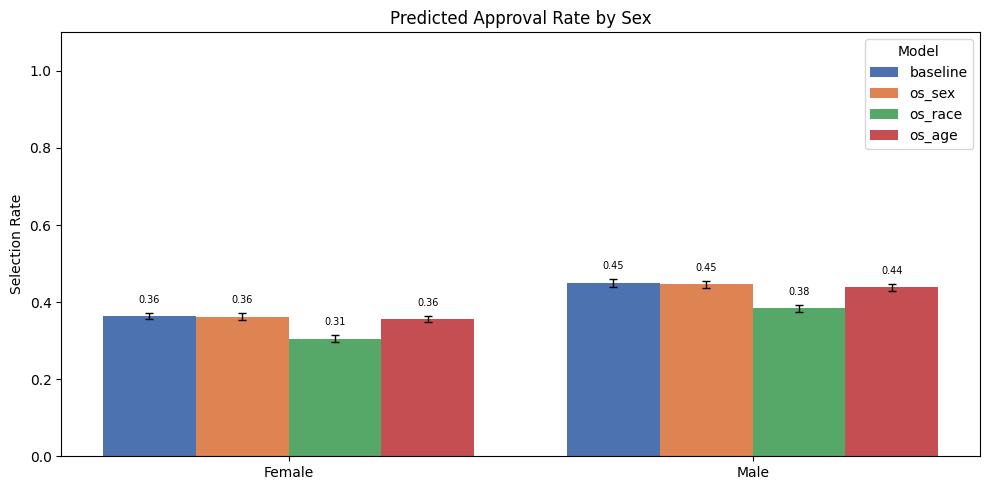

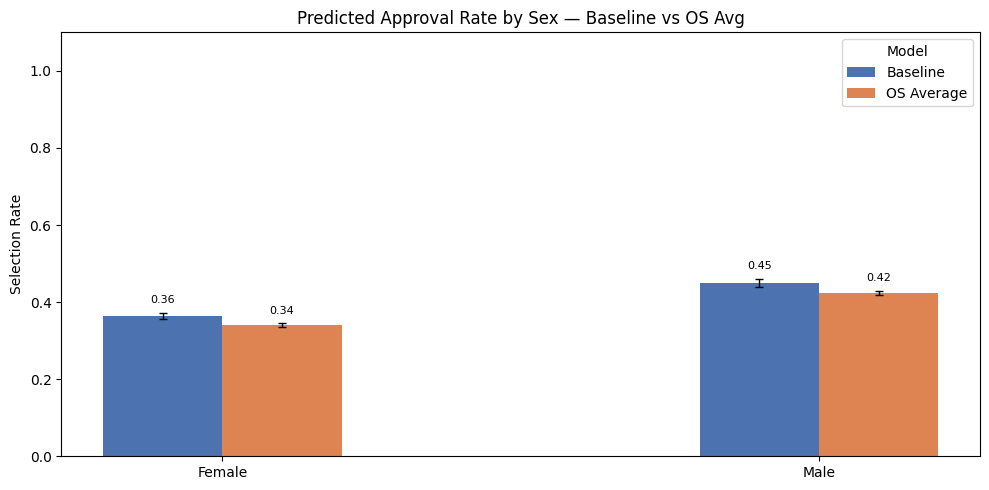

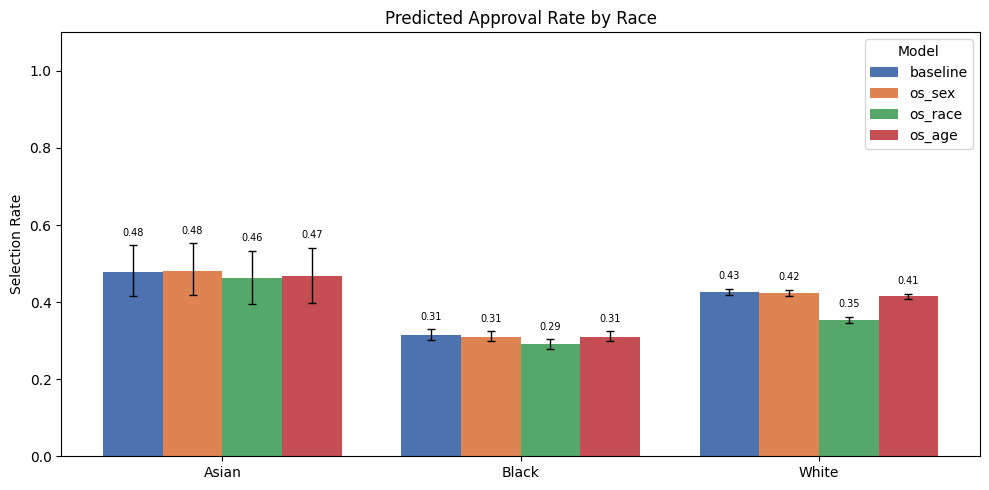

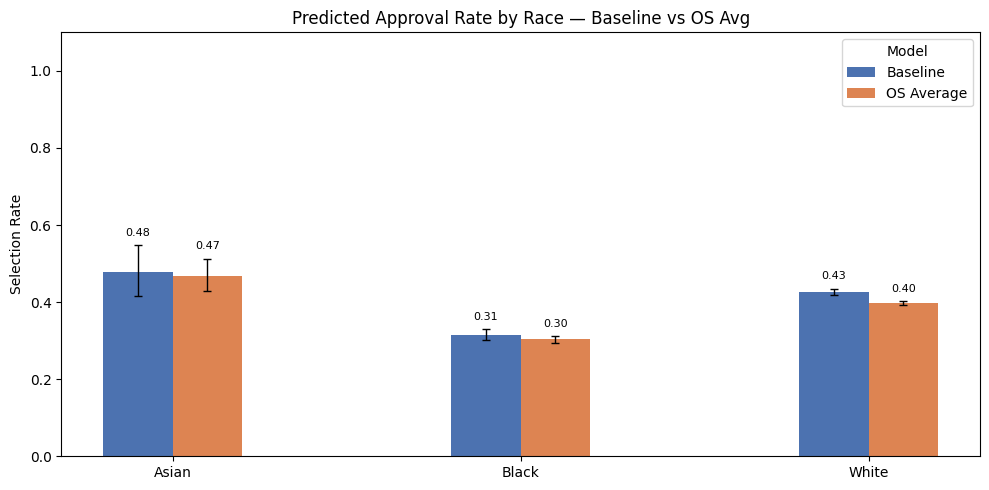

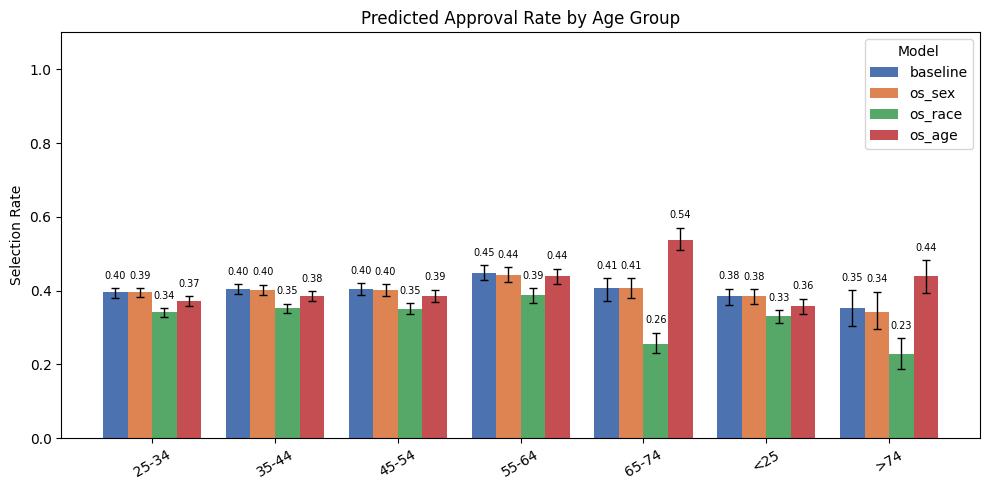

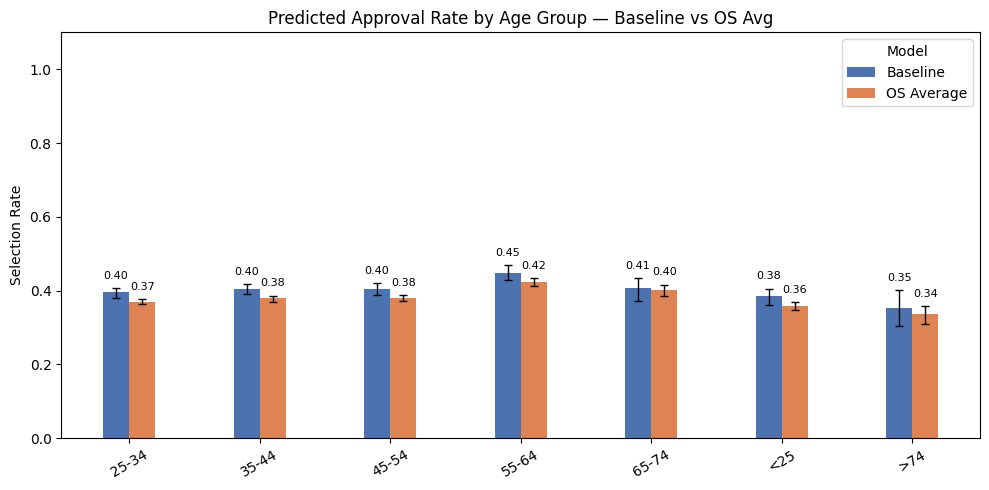

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

bar_width  = 0.2
colors     = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
output_dir = Path("charts")
output_dir.mkdir(exist_ok=True)

RNG = np.random.default_rng(42)

config_names = ["baseline", "os_sex", "os_race", "os_age"]

chart_configs = [
    ("SEX",  "sex_label",     "Predicted Approval Rate by Sex",       False, "os_sex"),
    ("RACE", "race_label",    "Predicted Approval Rate by Race",      False, "os_race"),
    ("AGE",  "applicant_age", "Predicted Approval Rate by Age Group", True,  "os_age"),
]

def get_selection_rates_per_seed(seed, name, group_col, groups, n_bootstrap=50, rng=None):
    """Bootstrap over test-set rows. Returns (n_bootstrap, n_groups) array."""
    y_score = predictions[(seed, name)]["y_score"]
    y_pred  = (y_score >= 0.5).astype(int)

    edf = X_test[SENSITIVE_COLS].copy()
    edf["y_true"]     = y_test.to_numpy()
    edf["y_pred"]     = y_pred
    edf["y_score"]    = y_score
    edf["sex_label"]  = edf["applicant_sex"].map({"1": "Male", "2": "Female"})
    edf["race_label"] = edf["applicant_race_1"].map({"2": "Asian", "3": "Black", "5": "White"})

    boot_rates = []
    for _ in range(n_bootstrap):
        boot = edf.sample(n=len(edf), replace=True, random_state=rng.integers(1e9))
        tbl  = fairness_table(boot, group_col).set_index("group")
        boot_rates.append(tbl.loc[groups, "selection_rate"].values)

    return np.array(boot_rates)  # (n_bootstrap, n_groups)

def compute_mean_ci(rates_per_seed, ci=95):
    """rates_per_seed is a list of (n_bootstrap, n_groups) arrays, one per seed."""
    arr  = np.concatenate(rates_per_seed, axis=0)  # (n_seeds * n_bootstrap, n_groups)
    mean = arr.mean(axis=0)

    lower = np.percentile(arr, (100 - ci) / 2, axis=0)
    upper = np.percentile(arr, 100 - (100 - ci) / 2, axis=0)

    return mean, (mean - lower, upper - mean)

def add_bar_labels(ax, bars, rates, cis, fontsize=7):
    upper_cis = cis[1]
    for bar, rate, ci in zip(bars, rates, upper_cis):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + ci + 0.02,
            f"{rate:.2f}",
            ha="center", va="bottom", fontsize=fontsize
        )

def setup_ax(ax, title, groups, x, rotate):
    ax.set_title(title)
    ax.set_ylabel("Selection Rate")
    ax.set_ylim(0, 1.1)
    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=30 if rotate else 0)
    ax.legend(title="Model")

for attr, group_col, title, rotate, os_key in chart_configs:
    groups = fairness_table(eval_dfs["baseline"], group_col)["group"].tolist()
    x      = np.arange(len(groups))

    # Precompute mean + CI per config
    means = {}
    cis   = {}
    for name in config_names:
        rates_per_seed         = [get_selection_rates_per_seed(seed, name, group_col, groups, rng=RNG) for seed in SEEDS]
        means[name], cis[name] = compute_mean_ci(rates_per_seed)

    # --- Chart 1: all models ---
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, name in enumerate(config_names):
        offset = (i - len(config_names) / 2 + 0.5) * bar_width
        bars   = ax.bar(x + offset, means[name], width=bar_width, label=name, color=colors[i])
        ax.errorbar(
            x + offset, means[name],
            yerr=[cis[name][0], cis[name][1]],
            fmt="none", color="black", capsize=3, linewidth=1
        )
        add_bar_labels(ax, bars, means[name], cis[name])
    setup_ax(ax, title, groups, x, rotate)
    plt.tight_layout()
    fig.savefig(output_dir / f"{attr}_all_models.png", dpi=150, bbox_inches="tight")
    plt.show()

    # --- Chart 2: baseline vs averaged os_ models ---
    os_keys = ["os_sex", "os_race", "os_age"]

    os_avg_per_seed = [
        np.mean([get_selection_rates_per_seed(seed, k, group_col, groups, rng=RNG) for k in os_keys], axis=0)
        for seed in SEEDS
    ]

    baseline_mean, baseline_ci = means["baseline"], cis["baseline"]
    os_avg_mean,   os_avg_ci   = compute_mean_ci(os_avg_per_seed)

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (label, mean, ci) in enumerate([
        ("Baseline",   baseline_mean, baseline_ci),
        ("OS Average", os_avg_mean,   os_avg_ci),
    ]):
        offset = (i - 1 + 0.5) * bar_width
        bars   = ax.bar(x + offset, mean, width=bar_width, label=label, color=colors[i])
        ax.errorbar(
            x + offset, mean,
            yerr=[ci[0], ci[1]],
            fmt="none", color="black", capsize=3, linewidth=1
        )
        add_bar_labels(ax, bars, mean, ci, fontsize=8)
    setup_ax(ax, f"{title} — Baseline vs OS Avg", groups, x, rotate)
    plt.tight_layout()
    fig.savefig(output_dir / f"{attr}_baseline_vs_os_avg.png", dpi=150, bbox_inches="tight")
    plt.show()

### Step 6: Save results

The results of the oversampled models are saved to output directories, this allows for easier access to the results without having to run the code. This is done for each models results and an overall models result.

In [18]:
# Output directory paths
sex_fairness_path  = OUT_DIR / "q2_fairness_by_sex.csv"
race_fairness_path = OUT_DIR / "q2_fairness_by_race.csv"
age_fairness_path  = OUT_DIR / "q2_fairness_by_age.csv"
metrics_path       = OUT_DIR / "q2_model_metrics.csv"

config_names = ["baseline", "os_sex", "os_race", "os_age"]

attr_configs = [
    ("sex",  "sex_label",     sex_fairness_path),
    ("race", "race_label",    race_fairness_path),
    ("age",  "applicant_age", age_fairness_path),
]

# Build combined fairness tables using averaged eval_dfs
for attr, group_col, path in attr_configs:
    combined = None
    for name in config_names:
        tbl = fairness_table(eval_dfs[name], group_col)
        if combined is None:
            combined = tbl[["group", "n", "base_positive_rate"]].copy()
        for metric in ["selection_rate", "true_positive_rate", "false_positive_rate", "selection_rate_minus_overall"]:
            combined[f"{metric}_{name}"] = tbl[metric].values
    combined.to_csv(path, index=False)

# Build combined metrics dataframe using averaged predictions
metric_rows = []
for name in config_names:
    avg_y_score = np.mean(
        [predictions[(seed, name)]["y_score"] for seed in SEEDS], axis=0
    )
    avg_y_pred = (avg_y_score >= 0.5).astype(int)

    sex_tbl  = fairness_table(eval_dfs[name], "sex_label")
    race_tbl = fairness_table(eval_dfs[name], "race_label")
    age_tbl  = fairness_table(eval_dfs[name], "applicant_age")

    sex_gap  = fairness_gap_summary(sex_tbl)
    race_gap = fairness_gap_summary(race_tbl)
    age_gap  = fairness_gap_summary(age_tbl)

    metric_rows.append({
        "model":                       name,
        "accuracy":                    accuracy_score(y_test, avg_y_pred),
        "balanced_accuracy":           balanced_accuracy_score(y_test, avg_y_pred),
        "roc_auc":                     roc_auc_score(y_test, avg_y_score),
        "sex_demographic_parity_gap":  float(sex_gap["demographic_parity_gap"]),
        "sex_equal_opportunity_gap":   float(sex_gap["equal_opportunity_gap"]),
        "sex_fpr_gap":                 float(sex_gap["false_positive_rate_gap"]),
        "race_demographic_parity_gap": float(race_gap["demographic_parity_gap"]),
        "race_equal_opportunity_gap":  float(race_gap["equal_opportunity_gap"]),
        "race_fpr_gap":                float(race_gap["false_positive_rate_gap"]),
        "age_demographic_parity_gap":  float(age_gap["demographic_parity_gap"]),
        "age_equal_opportunity_gap":   float(age_gap["equal_opportunity_gap"]),
        "age_fpr_gap":                 float(age_gap["false_positive_rate_gap"]),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(metrics_path, index=False)

print("Saved:")
print(" -", sex_fairness_path)
print(" -", race_fairness_path)
print(" -", age_fairness_path)
print(" -", metrics_path)

Saved:
 - eecs6320_q2_outputs - oversampled/q2_fairness_by_sex.csv
 - eecs6320_q2_outputs - oversampled/q2_fairness_by_race.csv
 - eecs6320_q2_outputs - oversampled/q2_fairness_by_age.csv
 - eecs6320_q2_outputs - oversampled/q2_model_metrics.csv


### Step 7: Oversampling Conclusion

Oversampling does not help debias the dataset in any meaningful way. In fact, all oversampled models perform worse than the Random Forest baseline model.
